# Week 2 - Exploratory Data Analysis (EDA)

## AI-Based Smart Queue and Time Management System Using RNN and LSTM

Bishwadeep Rai<br>
Westcliff University, California<br>
TECH 405: Artificial Neural Network and Deep Learning<br>
Professor Aashish Dhakal<br>
15 September 2026

## 1. Project Objective

This notebook gives a thorough **Exploratory Data Analysis (EDA)** of the **Call Centre Queue Simulation** data set. The final aim of the entire exercise is to develop a model using **RNN/LSTM model** which will predict the waiting time for the calls. This model can ultimately be used in a smart recommendation system which will suggest users whether to wait or not.


---

## 2. Dataset Overview

One full year is captured within this dataset of simulated call center data. One record indicates the arrival of a call, time at which the call was answered, time of completion of the service process, waiting time for the customer, duration of the service process, and if the call meets the standard response threshold.

---

## 3. Dataset Card

The dataset used is the Kaggle Call Centre Queue Simulation dataset with a license of CC BY-SA 4.0. The data has a total of 51,708 calls and is in a CSV file that has a size of 3.26 MB. The data was created using R `simmer` where there are four agents who work on weekdays from 8:00 AM to 6:00 PM with an average of five minutes of service time and a 60-second standard. The data is simulated, and hence it lacks any change in staffing, holidays, abandoned calls, or call categories.

## 4. Import Libraries

In [22]:
# Standard library
import os
import warnings

# Core data libraries
import pandas as pd
import numpy as np

# Visualisation libraries
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.cm as cm
import seaborn as sns

# Suppress minor warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.width', 200)

# Plot style
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 5)

print('All libraries imported successfully.')

All libraries imported successfully.


## 5. Load Dataset

In [23]:
# ---------------------------------------------------------------
# Update DATASET_PATH if you move the dataset file
# ---------------------------------------------------------------
DATASET_PATH = r'simulated_call_centre.csv\simulated_call_centre.csv'

if not os.path.exists(DATASET_PATH):
    raise FileNotFoundError(f'Dataset not found at: {DATASET_PATH}')

df = pd.read_csv(DATASET_PATH)

file_size_bytes = os.path.getsize(DATASET_PATH)
file_size_mb    = file_size_bytes / (1024 * 1024)

print(f'Dataset loaded successfully.')
print(f'File size : {file_size_bytes:,} bytes  ({file_size_mb:.2f} MB)')
print(f'Shape     : {df.shape[0]:,} rows x {df.shape[1]} columns')

Dataset loaded successfully.
File size : 3,418,761 bytes  (3.26 MB)
Shape     : 51,708 rows x 9 columns


## 6. Basic Inspection

In [24]:
print('=== Dataset Shape ===')
print(f'Rows   : {df.shape[0]:,}')
print(f'Columns: {df.shape[1]}')
print()
print('=== Column Names ===')
for i, col in enumerate(df.columns, 1):
    print(f'  {i}. {col}')

=== Dataset Shape ===
Rows   : 51,708
Columns: 9

=== Column Names ===
  1. call_id
  2. date
  3. daily_caller
  4. call_started
  5. call_answered
  6. call_ended
  7. wait_length
  8. service_length
  9. meets_standard


## 7. Data Types and Structure

In [25]:
print('=== Data Types ===')
print(df.dtypes)
print()
print('=== DataFrame Info ===')
df.info()

=== Data Types ===
call_id           int64
date                str
daily_caller      int64
call_started        str
call_answered       str
call_ended          str
wait_length       int64
service_length    int64
meets_standard     bool
dtype: object

=== DataFrame Info ===
<class 'pandas.DataFrame'>
RangeIndex: 51708 entries, 0 to 51707
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   call_id         51708 non-null  int64
 1   date            51708 non-null  str  
 2   daily_caller    51708 non-null  int64
 3   call_started    51708 non-null  str  
 4   call_answered   51708 non-null  str  
 5   call_ended      51708 non-null  str  
 6   wait_length     51708 non-null  int64
 7   service_length  51708 non-null  int64
 8   meets_standard  51708 non-null  bool 
dtypes: bool(1), int64(4), str(4)
memory usage: 5.2 MB


The date and time fields initially use text format and are converted before analysis. The duration fields are integers, and `meets_standard` is Boolean.

## 8. Random Samples

In [26]:
print('=== 5 Random Sample Rows ===')
df.sample(5, random_state=42)

=== 5 Random Sample Rows ===


,call_id,date,daily_caller,call_started,call_answered,call_ended,wait_length,service_length,meets_standard
7673,7674,2021-03-15,67,12:26:53 PM,12:26:53 PM,12:27:57 PM,0,64,True
20436,20437,2021-06-25,163,5:41:16 PM,5:41:16 PM,5:42:28 PM,0,72,True
14737,14738,2021-05-13,76,1:05:31 PM,1:05:31 PM,1:16:15 PM,0,644,True
43740,43741,2021-11-22,72,10:43:22 AM,10:43:22 AM,10:50:06 AM,0,404,True
3227,3228,2021-02-02,77,1:21:28 PM,1:21:28 PM,1:25:41 PM,0,253,True


**Observation:** Each row represents one call event. Timestamps use 12-hour AM/PM format. The majority of rows show `wait_length = 0` and `meets_standard = True`, indicating most callers are answered immediately without queuing.

## 9. Descriptive Statistics

In [27]:
print('=== Descriptive Statistics (All Columns) ===')
df.describe(include='all')

=== Descriptive Statistics (All Columns) ===


,call_id,date,daily_caller,call_started,call_answered,call_ended,wait_length,service_length,meets_standard
count,51708.0000,51708,51708.0000,51708,51708,51708,51708.0000,51708.0000,51708
unique,NaN,261,NaN,27403,27366,27486,NaN,NaN,2
top,NaN,2021-12-10,NaN,8:00:00 AM,8:00:00 AM,11:54:17 AM,NaN,NaN,True
freq,NaN,297,NaN,261,261,8,NaN,NaN,47481
mean,25854.5000,NaN,104.1932,NaN,NaN,NaN,17.0349,299.1026,NaN
std,14926.9582,NaN,64.9529,NaN,NaN,NaN,64.0608,299.8658,NaN
min,1.0000,NaN,1.0000,NaN,NaN,NaN,0.0000,0.0000,NaN
25%,12927.7500,NaN,50.0000,NaN,NaN,NaN,0.0000,86.0000,NaN
50%,25854.5000,NaN,100.0000,NaN,NaN,NaN,0.0000,208.0000,NaN
75%,38781.2500,NaN,150.0000,NaN,NaN,NaN,0.0000,414.0000,NaN


In [28]:
# Focused on numeric columns only
numeric_cols = df.select_dtypes(include='number').columns.tolist()
print('Numeric columns:', numeric_cols)
print()
df[numeric_cols].describe().T

Numeric columns: ['call_id', 'daily_caller', 'wait_length', 'service_length']



,count,mean,std,min,25%,50%,75%,max
call_id,51708.0000,25854.5000,14926.9582,1.0000,12927.7500,25854.5000,38781.2500,51708.0000
daily_caller,51708.0000,104.1932,64.9529,1.0000,50.0000,100.0000,150.0000,297.0000
wait_length,51708.0000,17.0349,64.0608,0.0000,0.0000,0.0000,0.0000,983.0000
service_length,51708.0000,299.1026,299.8658,0.0000,86.0000,208.0000,414.0000,3110.0000


In [29]:
print('=== Unique Values per Column ===')
for col in df.columns:
    print(f'  {col:<20}: {df[col].nunique():>6} unique values')

=== Unique Values per Column ===
  call_id             :  51708 unique values
  date                :    261 unique values
  daily_caller        :    297 unique values
  call_started        :  27403 unique values
  call_answered       :  27366 unique values
  call_ended          :  27486 unique values
  wait_length         :    575 unique values
  service_length      :   1719 unique values
  meets_standard      :      2 unique values


The dataset has 51,708 sequential call IDs, up to 297 callers per day, a mean wait of about 17 seconds, a median wait of zero, and an average service time of about 299 seconds. The standard field has two values, True and False.

## 10. Parse Datetime Columns

Before quality checks and temporal analysis, we convert the string time columns to proper datetime objects.

In [30]:
# Parse date column
df['date'] = pd.to_datetime(df['date'], format='%Y-%m-%d')

# Build full datetime strings before parsing
date_str = df['date'].dt.strftime('%Y-%m-%d')

df['call_started_dt']  = pd.to_datetime(
    date_str + ' ' + df['call_started'],  format='%Y-%m-%d %I:%M:%S %p')
df['call_answered_dt'] = pd.to_datetime(
    date_str + ' ' + df['call_answered'], format='%Y-%m-%d %I:%M:%S %p')
df['call_ended_dt']    = pd.to_datetime(
    date_str + ' ' + df['call_ended'],    format='%Y-%m-%d %I:%M:%S %p')

print('Datetime parsing successful.')
print(f'Date range: {df["date"].min().date()} to {df["date"].max().date()}')
print(f'Unique operating days: {df["date"].nunique()}')

Datetime parsing successful.
Date range: 2021-01-01 to 2021-12-31
Unique operating days: 261


## 11. Missing Values

In [31]:
missing     = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(4)

missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print('=== Missing Value Report ===')
print(missing_df.to_string())
print()
if missing.sum() == 0:
    print('No missing values found in any column.')
else:
    print(f'Total missing values: {missing.sum()}')

=== Missing Value Report ===
                  Missing Count  Missing %
call_id                       0     0.0000
date                          0     0.0000
daily_caller                  0     0.0000
call_started                  0     0.0000
call_answered                 0     0.0000
call_ended                    0     0.0000
wait_length                   0     0.0000
service_length                0     0.0000
meets_standard                0     0.0000
call_started_dt               0     0.0000
call_answered_dt              0     0.0000
call_ended_dt                 0     0.0000

No missing values found in any column.


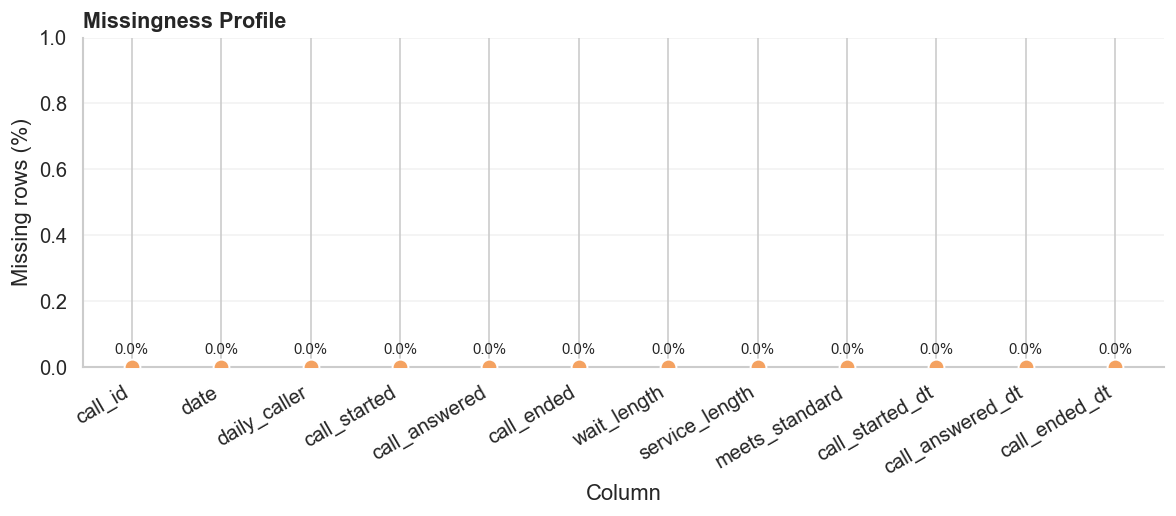

In [32]:
fig, ax = plt.subplots(figsize=(10, 4.5))
positions = np.arange(len(missing_pct))
ax.vlines(positions, 0, missing_pct.values, color='#246a73', linewidth=2.5)
ax.scatter(positions, missing_pct.values, s=90, color='#f4a261', edgecolor='white', linewidth=1.2, zorder=3)
for position, value in zip(positions, missing_pct.values):
    ax.annotate(f'{value:.1f}%', (position, value), xytext=(0, 8),
                textcoords='offset points', ha='center', fontsize=9)
ax.set_title('Missingness Profile', fontsize=13, fontweight='bold', loc='left')
ax.set_xlabel('Column')
ax.set_ylabel('Missing rows (%)')
ax.set_xticks(positions)
ax.set_xticklabels(missing_pct.index, rotation=30, ha='right')
ax.set_ylim(0, max(1, missing_pct.max() + 0.4))
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.savefig('fig_missing_values.png', dpi=150, bbox_inches='tight')
plt.show()

**Result:** There are **zero missing values** across all 9 columns. This is expected for simulated data generated by a controlled DES model.

## 12. Duplicate Rows

In [33]:
n_dup = df.duplicated().sum()
print(f'Total duplicate rows: {n_dup}')
if n_dup == 0:
    print('No duplicate rows found.')
else:
    print(f'{n_dup} duplicates found:')
    print(df[df.duplicated()])

Total duplicate rows: 0
No duplicate rows found.


**Result:** **Zero duplicate rows.** Each call has a unique `call_id`; duplication would indicate a data generation error, which did not occur here.

## 13. Data Quality Checks

In [34]:
print('=== Check 1: Missing, Duplicate, and Corrupt Values ===')
print(f'  Missing cells              : {int(df.isna().sum().sum())}')
print(f'  Duplicate rows             : {int(df.duplicated().sum())}')
print(f'  Duplicate call_id values   : {int(df["call_id"].duplicated().sum())}')
print(f'  Negative wait values       : {int((df["wait_length"] < 0).sum())}')
print(f'  Negative service values    : {int((df["service_length"] < 0).sum())}')
print(f'  Invalid timestamp order    : {int((
    (df["call_answered_dt"] < df["call_started_dt"]) |
    (df["call_ended_dt"] < df["call_answered_dt"])
).sum())}')

=== Check 1: Missing, Duplicate, and Corrupt Values ===
  Missing cells              : 0
  Duplicate rows             : 0
  Duplicate call_id values   : 0
  Negative wait values       : 0
  Negative service values    : 0
  Invalid timestamp order    : 0


In [35]:
print('=== Check 2: Zero Service Duration ===')
zero_service = (df['service_length'] == 0).sum()
print(f'  Rows with service_length == 0: {zero_service} ({zero_service/len(df)*100:.3f}%)')
print('  Possible interpretation: calls answered and immediately disconnected,')
print('  or simulation edge cases. Should be flagged before modelling.')
if zero_service > 0:
    print()
    print('  Sample rows:')
    cols_show = ['call_id','date','wait_length','service_length','meets_standard']
    print(df[df['service_length'] == 0][cols_show].head(5).to_string(index=False))

=== Check 2: Zero Service Duration ===
  Rows with service_length == 0: 88 (0.170%)
  Possible interpretation: calls answered and immediately disconnected,
  or simulation edge cases. Should be flagged before modelling.

  Sample rows:
 call_id       date  wait_length  service_length  meets_standard
     308 2021-01-05            0               0            True
     673 2021-01-07            0               0            True
    1610 2021-01-18            0               0            True
    1995 2021-01-20            0               0            True
    2455 2021-01-26            0               0            True


In [36]:
print('=== Check 3: meets_standard Logic Consistency ===')
computed_standard = df['wait_length'] <= 60
mismatch = (computed_standard != df['meets_standard']).sum()
print(f'  Rows where (wait_length <= 60) != meets_standard: {mismatch}')
if mismatch == 0:
    print('  meets_standard is perfectly consistent with the 60-second threshold rule.')

=== Check 3: meets_standard Logic Consistency ===
  Rows where (wait_length <= 60) != meets_standard: 0
  meets_standard is perfectly consistent with the 60-second threshold rule.


In [37]:
print('=== Check 4: Calls Outside Operating Hours ===')
df['hour_of_call'] = df['call_started_dt'].dt.hour
out_of_hours = df[(df['hour_of_call'] < 8) | (df['hour_of_call'] >= 18)]
print(f'  Calls outside 8am-6pm: {len(out_of_hours)}')
if len(out_of_hours) == 0:
    print('  All calls are within operating hours (8:00 AM - 6:00 PM).')

=== Check 4: Calls Outside Operating Hours ===
  Calls outside 8am-6pm: 0
  All calls are within operating hours (8:00 AM - 6:00 PM).


In [38]:
print('=== Check 5: Weekend Calls ===')
weekend_calls = df[df['date'].dt.dayofweek >= 5]
print(f'  Calls on weekends: {len(weekend_calls)}')
if len(weekend_calls) == 0:
    print('  No weekend calls. Dataset is Monday-Friday only, as expected.')

=== Check 5: Weekend Calls ===
  Calls on weekends: 0
  No weekend calls. Dataset is Monday-Friday only, as expected.


In [39]:
print('=== Check 6: Extreme service_length Outliers ===')
q99     = df['service_length'].quantile(0.99)
extreme = (df['service_length'] > q99).sum()
print(f'  99th percentile of service_length: {q99:.0f} seconds ({q99/60:.1f} min)')
print(f'  Rows above 99th percentile       : {extreme} ({extreme/len(df)*100:.2f}%)')
print(f'  Maximum service_length            : {df["service_length"].max()} seconds ({df["service_length"].max()/60:.1f} min)')
print('  Long but plausible for an exponential service distribution.')
print('  Consider capping at the 99th percentile before LSTM training.')

=== Check 6: Extreme service_length Outliers ===
  99th percentile of service_length: 1390 seconds (23.2 min)
  Rows above 99th percentile       : 516 (1.00%)
  Maximum service_length            : 3110 seconds (51.8 min)
  Long but plausible for an exponential service distribution.
  Consider capping at the 99th percentile before LSTM training.


### Data Quality Summary

The dataset has no missing cells, duplicate rows, duplicate IDs, negative durations, or invalid timestamp order. It contains 88 zero-service records and 516 service times above the 99th percentile. These should be reviewed before future modelling, while the remaining long waits are plausible in a queue simulation.

## 14. Target Variable

The primary target is **`wait_length`**, measured in seconds. It is continuous, directly useful for queue recommendations, and therefore this is a regression problem. `meets_standard` is derived from the target (`wait_length <= 60`), so it is not used as the primary target. `service_length` describes the completed call and can be used only as a historical feature in later modelling.

## 15. Target Distribution Analysis: `wait_length`

In [40]:
wl = df['wait_length']

stats = {
    'Count'              : len(wl),
    'Mean (seconds)'     : wl.mean(),
    'Median (seconds)'   : wl.median(),
    'Std Dev (seconds)'  : wl.std(),
    'Min'                : wl.min(),
    'Max'                : wl.max(),
    'Skewness'           : wl.skew(),
    'Kurtosis'           : wl.kurtosis(),
    '25th percentile'    : wl.quantile(0.25),
    '50th percentile'    : wl.quantile(0.50),
    '75th percentile'    : wl.quantile(0.75),
    '90th percentile'    : wl.quantile(0.90),
    '95th percentile'    : wl.quantile(0.95),
    '99th percentile'    : wl.quantile(0.99),
    'Zero wait count'    : (wl == 0).sum(),
    'Zero wait %'        : f"{(wl == 0).mean()*100:.1f}%",
    'Non-zero wait count': (wl > 0).sum(),
}

print('=== wait_length (seconds) — Summary Statistics ===')
for k, v in stats.items():
    if isinstance(v, float):
        print(f'  {k:<25}: {v:.4f}')
    else:
        print(f'  {k:<25}: {v}')

=== wait_length (seconds) — Summary Statistics ===
  Count                    : 51708
  Mean (seconds)           : 17.0349
  Median (seconds)         : 0.0000
  Std Dev (seconds)        : 64.0608
  Min                      : 0
  Max                      : 983
  Skewness                 : 5.2595
  Kurtosis                 : 33.9894
  25th percentile          : 0.0000
  50th percentile          : 0.0000
  75th percentile          : 0.0000
  90th percentile          : 32.0000
  95th percentile          : 129.0000
  99th percentile          : 347.0000
  Zero wait count          : 45291
  Zero wait %              : 87.6%
  Non-zero wait count      : 6417


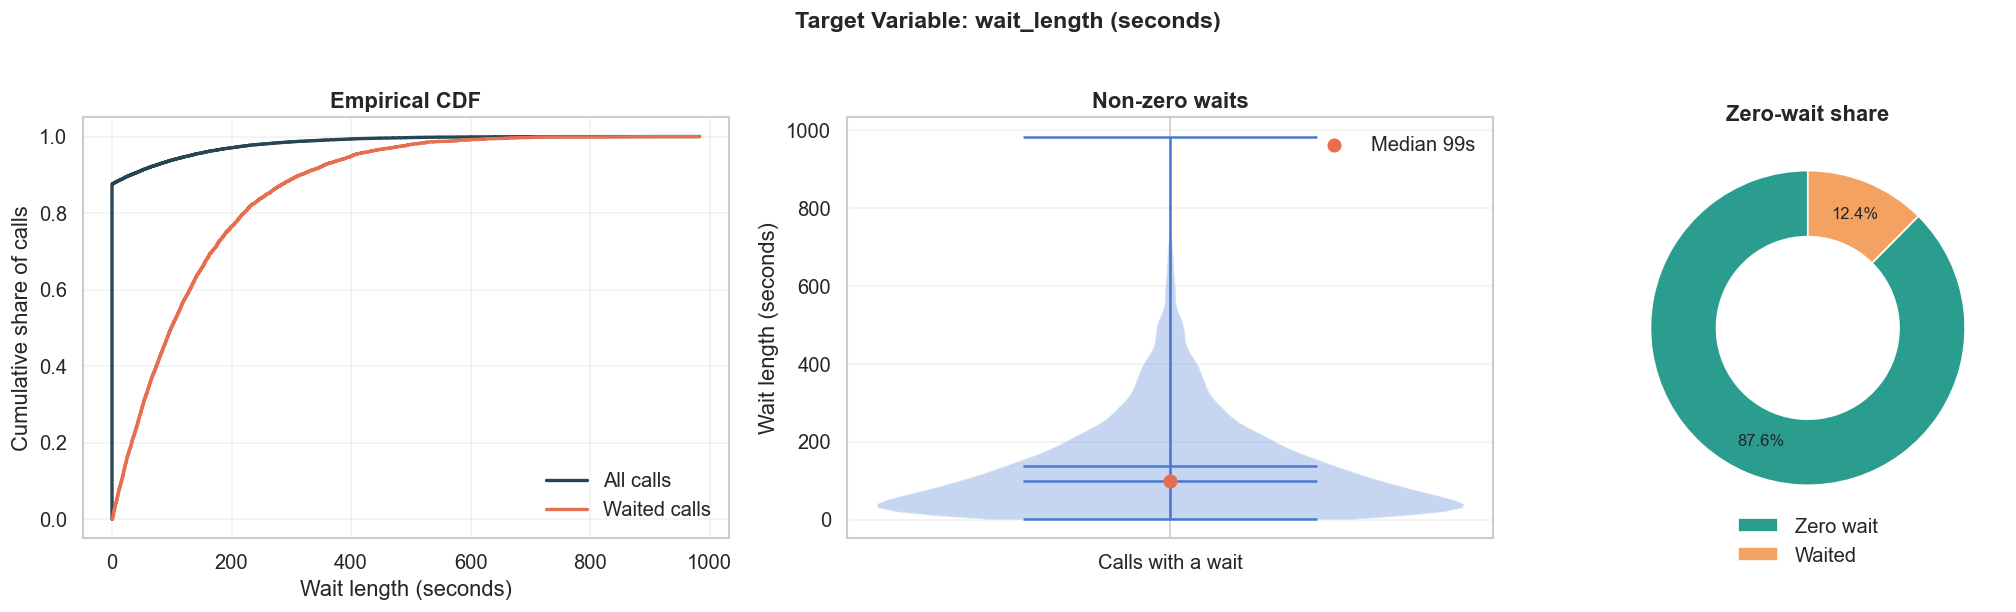

In [41]:
wl_nz = wl[wl > 0]
fig, axes = plt.subplots(1, 3, figsize=(17, 5), gridspec_kw={'width_ratios': [1.15, 1.15, 0.7]})

# ECDFs show the zero-inflated target without relying on repeated histograms.
for values, color, label in [(wl, '#264653', 'All calls'), (wl_nz, '#e76f51', 'Waited calls')]:
    sorted_values = np.sort(values)
    y = np.arange(1, len(sorted_values) + 1) / len(sorted_values)
    axes[0].step(sorted_values, y, where='post', color=color, linewidth=2, label=label)
axes[0].set_title('Empirical CDF', fontweight='bold')
axes[0].set_xlabel('Wait length (seconds)')
axes[0].set_ylabel('Cumulative share of calls')
axes[0].legend(frameon=False)
axes[0].grid(alpha=0.25)

axes[1].violinplot([wl_nz], positions=[1], showmeans=True, showmedians=True, widths=0.75)
axes[1].scatter([1], [wl_nz.median()], color='#e76f51', s=55, zorder=3, label=f'Median {wl_nz.median():.0f}s')
axes[1].set_title('Non-zero waits', fontweight='bold')
axes[1].set_ylabel('Wait length (seconds)')
axes[1].set_xticks([1], ['Calls with a wait'])
axes[1].legend(frameon=False)
axes[1].grid(axis='y', alpha=0.25)

zero_share = (wl == 0).mean() * 100
axes[2].pie([zero_share, 100 - zero_share], startangle=90,
            colors=['#2a9d8f', '#f4a261'], wedgeprops={'width': 0.42, 'edgecolor': 'white'},
            autopct='%1.1f%%', pctdistance=0.78, textprops={'fontsize': 10})
axes[2].set_title('Zero-wait share', fontweight='bold')
axes[2].legend(['Zero wait', 'Waited'], loc='lower center', bbox_to_anchor=(0.5, -0.15), frameon=False)

plt.suptitle('Target Variable: wait_length (seconds)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation:** `wait_length` is zero-inflated and right-skewed: most calls are answered immediately, while a smaller group waits substantially longer. This is a regression problem, not a classification problem. A log transformation and MAE/Huber loss should be considered for later modelling.

## 16. Feature Distributions

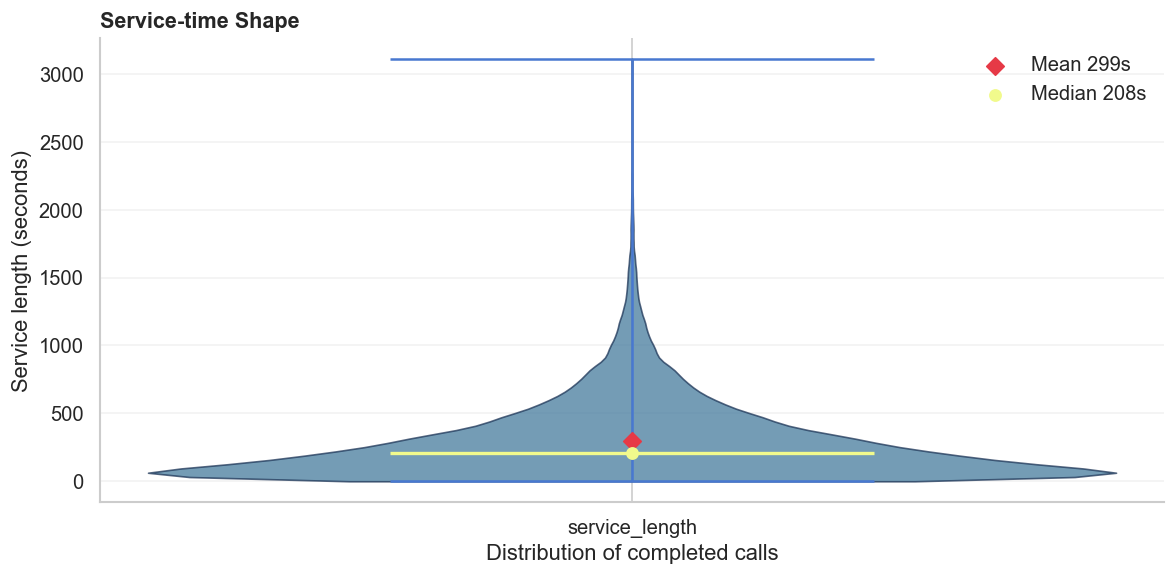

service_length -- Mean: 299.1s | Median: 208s | Skewness: 2.03


In [42]:
sl = df['service_length']

fig, ax = plt.subplots(figsize=(10, 5))
parts = ax.violinplot([sl], positions=[0], showmeans=False, showmedians=True, showextrema=True,
                      widths=0.8)
for body in parts['bodies']:
    body.set_facecolor('#457b9d')
    body.set_edgecolor('#1d3557')
    body.set_alpha(0.75)
parts['cmedians'].set_color('#f1fa8c')
parts['cmedians'].set_linewidth(2)
ax.scatter([0], [sl.mean()], color='#e63946', marker='D', s=55, zorder=3, label=f'Mean {sl.mean():.0f}s')
ax.scatter([0], [sl.median()], color='#f1fa8c', marker='o', s=45, zorder=3, label=f'Median {sl.median():.0f}s')
ax.set_title('Service-time Shape', fontweight='bold', fontsize=13, loc='left')
ax.set_xlabel('Distribution of completed calls')
ax.set_ylabel('Service length (seconds)')
ax.set_xticks([0], ['service_length'])
ax.legend(frameon=False)
ax.grid(axis='y', alpha=0.25)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('fig_service_length.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'service_length -- Mean: {sl.mean():.1f}s | Median: {sl.median():.0f}s | Skewness: {sl.skew():.2f}')

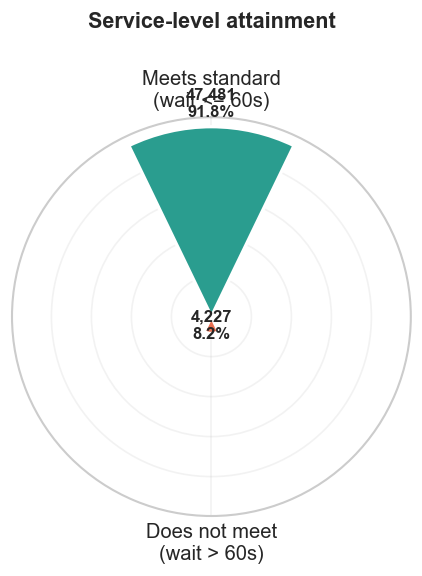

meets_standard
True    91.8252
False    8.1748
Name: proportion, dtype: float64


In [43]:
ms_counts = df['meets_standard'].value_counts().reindex([True, False], fill_value=0)
ms_pct = df['meets_standard'].value_counts(normalize=True).reindex([True, False], fill_value=0) * 100

fig, ax = plt.subplots(figsize=(7, 5), subplot_kw={'projection': 'polar'})
angles = np.linspace(0, 2 * np.pi, len(ms_counts), endpoint=False)
values = ms_counts.values
bars = ax.bar(angles, values, width=0.9, color=['#2a9d8f', '#e76f51'], edgecolor='white', linewidth=2)
ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)
ax.set_xticks(angles)
ax.set_xticklabels(['Meets standard\n(wait <= 60s)', 'Does not meet\n(wait > 60s)'])
ax.set_title('Service-level attainment', fontweight='bold', fontsize=13, pad=25)
ax.set_yticklabels([])
ax.grid(alpha=0.25)
for bar, count, pct in zip(bars, values, ms_pct.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + values.max() * 0.04,
            f'{count:,}\n{pct:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_meets_standard.png', dpi=150, bbox_inches='tight')
plt.show()
print(ms_pct)

Service time is right-skewed, with a mean of about 299 seconds and a median of 208 seconds. About 91.8% of calls meet the 60-second standard, so this field would be imbalanced if used for classification.

## 17. Temporal Analysis

In [44]:
# Engineer temporal features
df['day_of_week']   = df['date'].dt.day_name()
df['day_of_week_n'] = df['date'].dt.dayofweek
df['month']         = df['date'].dt.month
df['week_of_year']  = df['date'].dt.isocalendar().week.astype(int)

print('Temporal features added.')
print(df[['call_id','date','hour_of_call','day_of_week','month']].head(3))

Temporal features added.
   call_id       date  hour_of_call day_of_week  month
0        1 2021-01-01             8      Friday      1
1        2 2021-01-01             8      Friday      1
2        3 2021-01-01             8      Friday      1


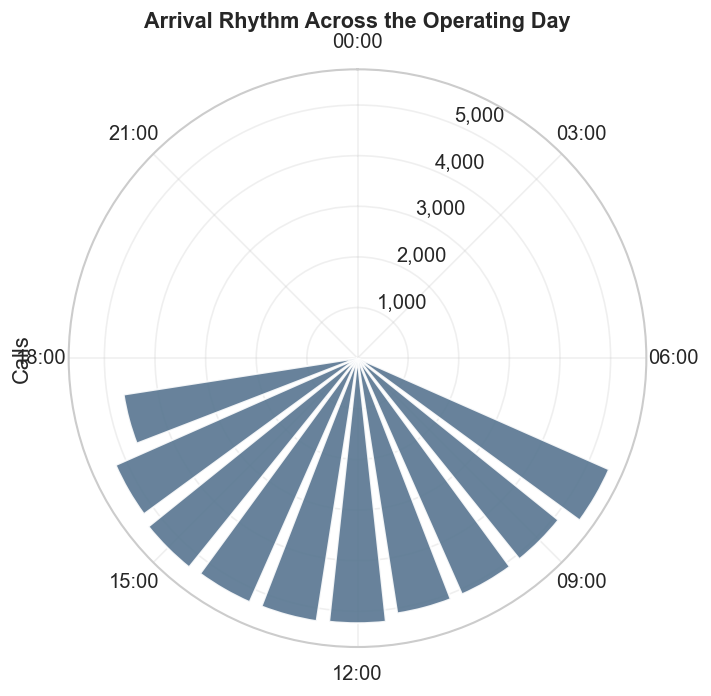

In [45]:
hourly_counts = df.groupby('hour_of_call').size().reset_index(name='call_count')

fig, ax = plt.subplots(figsize=(10, 6), subplot_kw={'projection': 'polar'})
angles = 2 * np.pi * hourly_counts['hour_of_call'] / 24
bars = ax.bar(angles, hourly_counts['call_count'], width=2 * np.pi / 24 * 0.82,
              color='#577590', edgecolor='white', linewidth=1.2, alpha=0.9)
ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)
ax.set_xticks(2 * np.pi * np.arange(0, 24, 3) / 24)
ax.set_xticklabels([f'{h:02d}:00' for h in range(0, 24, 3)])
ax.set_title('Arrival Rhythm Across the Operating Day', fontweight='bold', fontsize=13, pad=25)
ax.set_ylabel('Calls', labelpad=22)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig_hourly_arrivals.png', dpi=150, bbox_inches='tight')
plt.show()

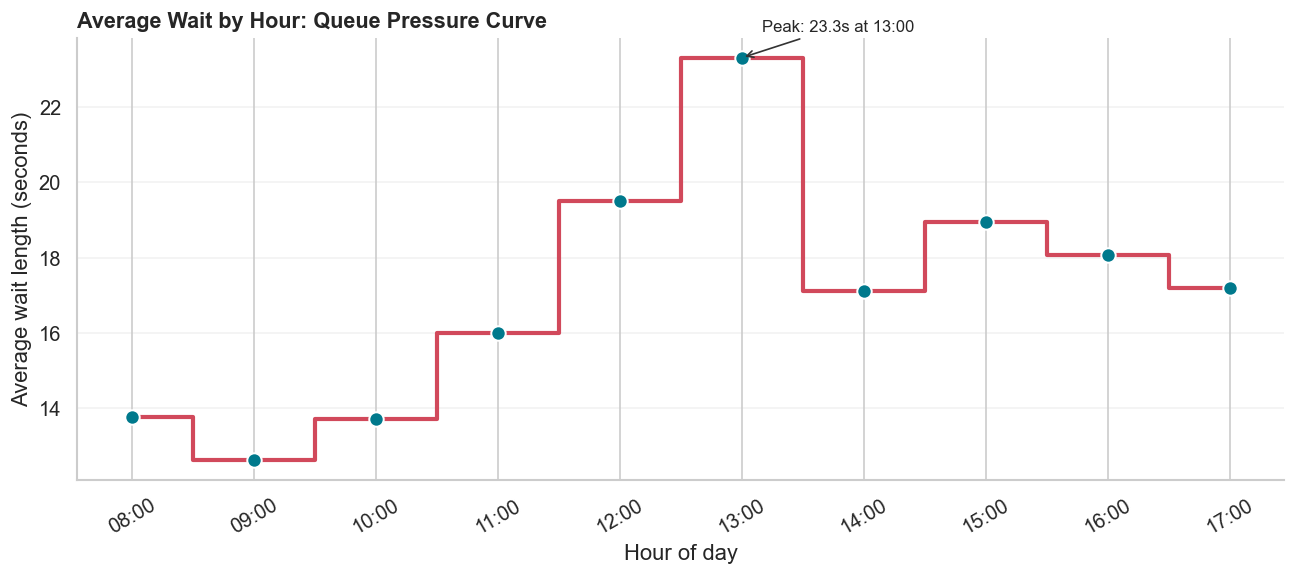

In [46]:
hourly_wait = df.groupby('hour_of_call')['wait_length'].mean().reset_index()

fig, ax = plt.subplots(figsize=(11, 5))
ax.step(hourly_wait['hour_of_call'], hourly_wait['wait_length'], where='mid',
         color='#d1495b', linewidth=2.5)
ax.scatter(hourly_wait['hour_of_call'], hourly_wait['wait_length'],
           s=75, color='#00798c', edgecolor='white', linewidth=1.2, zorder=3)
peak = hourly_wait.loc[hourly_wait['wait_length'].idxmax()]
ax.annotate(f'Peak: {peak.wait_length:.1f}s at {int(peak.hour_of_call):02d}:00',
            xy=(peak.hour_of_call, peak.wait_length), xytext=(12, 16),
            textcoords='offset points', arrowprops={'arrowstyle': '->', 'color': '#333333'},
            fontsize=10)
ax.set_title('Average Wait by Hour: Queue Pressure Curve', fontweight='bold', fontsize=13, loc='left')
ax.set_xlabel('Hour of day')
ax.set_ylabel('Average wait length (seconds)')
ax.set_xticks(hourly_wait['hour_of_call'])
ax.set_xticklabels([f'{h:02d}:00' for h in hourly_wait['hour_of_call']], rotation=30)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.savefig('fig_hourly_wait.png', dpi=150, bbox_inches='tight')
plt.show()

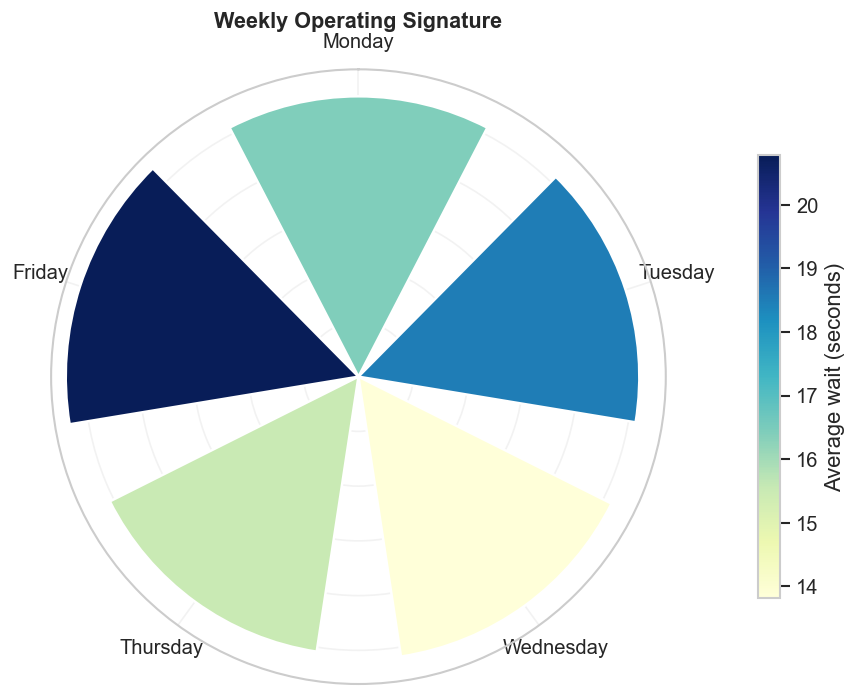

In [47]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
dow_counts = df.groupby('day_of_week').size().reindex(day_order).reset_index(name='call_count')
dow_wait = df.groupby('day_of_week')['wait_length'].mean().reindex(day_order).reset_index()

fig, ax = plt.subplots(figsize=(10, 6), subplot_kw={'projection': 'polar'})
angles = np.linspace(0, 2 * np.pi, len(day_order), endpoint=False)
width = 2 * np.pi / len(day_order) * 0.76
norm = plt.Normalize(dow_wait['wait_length'].min(), dow_wait['wait_length'].max())
colors = plt.cm.YlGnBu(norm(dow_wait['wait_length']))
ax.bar(angles, dow_counts['call_count'], width=width, color=colors, edgecolor='white', linewidth=1.5)
ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)
ax.set_xticks(angles)
ax.set_xticklabels(day_order)
ax.set_title('Weekly Operating Signature', fontsize=13, fontweight='bold', pad=25)
ax.set_yticklabels([])
ax.grid(alpha=0.25)
sm = plt.cm.ScalarMappable(cmap='YlGnBu', norm=norm)
sm.set_array([])
fig.colorbar(sm, ax=ax, pad=0.08, shrink=0.72, label='Average wait (seconds)')
plt.tight_layout()
plt.savefig('fig_dow_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

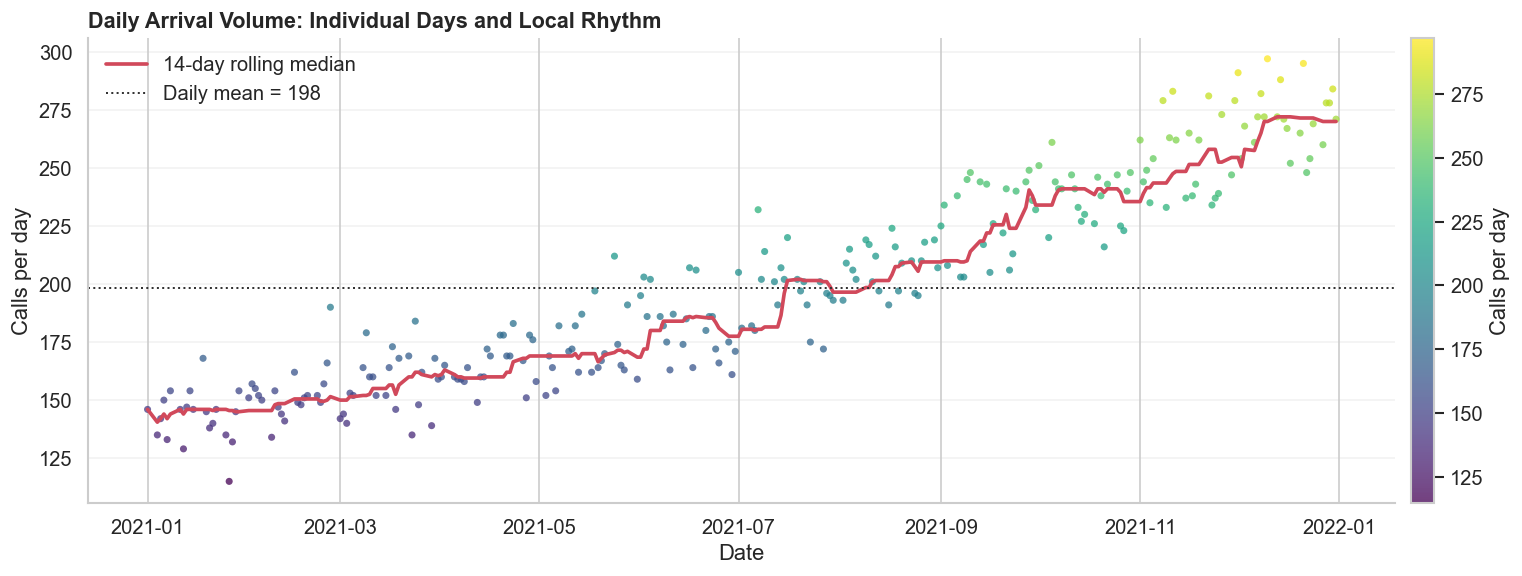

Daily call volume -- Mean: 198.1 | Min: 115 | Max: 297


In [48]:
calls_per_day = df.groupby('date').size().reset_index(name='call_count')
calls_per_day['rolling_14d'] = calls_per_day['call_count'].rolling(14, min_periods=1).median()

fig, ax = plt.subplots(figsize=(14, 5))
scatter = ax.scatter(calls_per_day['date'], calls_per_day['call_count'],
                     c=calls_per_day['call_count'], cmap='viridis', s=18, alpha=0.75, linewidth=0)
ax.plot(calls_per_day['date'], calls_per_day['rolling_14d'], color='#d1495b', linewidth=2.2,
        label='14-day rolling median')
ax.axhline(calls_per_day['call_count'].mean(), color='#333333', linestyle=':', linewidth=1.2,
           label=f'Daily mean = {calls_per_day["call_count"].mean():.0f}')
ax.set_title('Daily Arrival Volume: Individual Days and Local Rhythm', fontweight='bold', fontsize=13, loc='left')
ax.set_xlabel('Date')
ax.set_ylabel('Calls per day')
ax.legend(frameon=False)
ax.grid(axis='y', alpha=0.25)
ax.spines[['top', 'right']].set_visible(False)
fig.colorbar(scatter, ax=ax, pad=0.01, label='Calls per day')
plt.tight_layout()
plt.savefig('fig_daily_volume.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Daily call volume -- Mean: {calls_per_day["call_count"].mean():.1f} | '
      f'Min: {calls_per_day["call_count"].min()} | Max: {calls_per_day["call_count"].max()}')

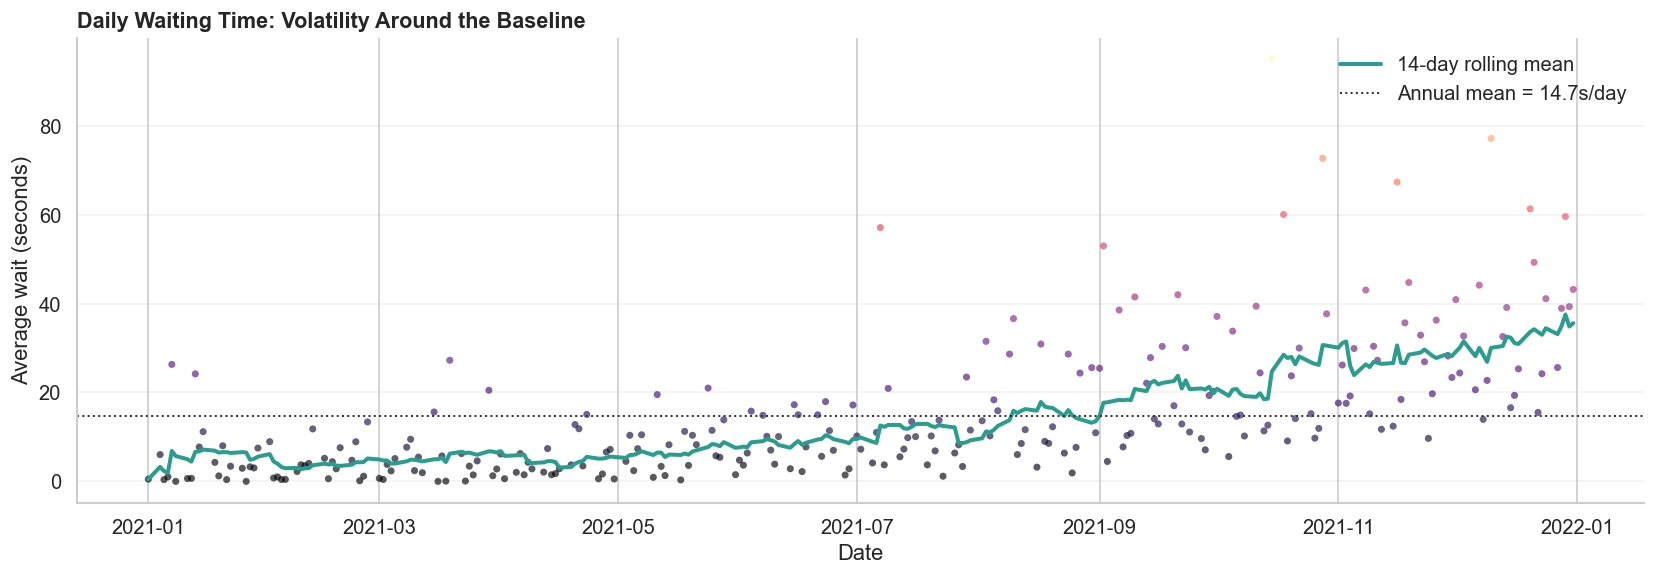

In [49]:
daily_avg_wait = df.groupby('date')['wait_length'].mean().reset_index()
daily_avg_wait['rolling_14d'] = daily_avg_wait['wait_length'].rolling(14, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.scatter(daily_avg_wait['date'], daily_avg_wait['wait_length'],
           c=daily_avg_wait['wait_length'], cmap='magma', s=18, alpha=0.65, linewidth=0)
ax.plot(daily_avg_wait['date'], daily_avg_wait['rolling_14d'], color='#2a9d8f', linewidth=2.4,
        label='14-day rolling mean')
ax.axhline(daily_avg_wait['wait_length'].mean(), color='#333333', linestyle=':', linewidth=1.2,
           label=f'Annual mean = {daily_avg_wait["wait_length"].mean():.1f}s/day')
ax.set_title('Daily Waiting Time: Volatility Around the Baseline', fontweight='bold', fontsize=13, loc='left')
ax.set_xlabel('Date')
ax.set_ylabel('Average wait (seconds)')
ax.legend(frameon=False)
ax.grid(axis='y', alpha=0.25)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('fig_daily_wait.png', dpi=150, bbox_inches='tight')
plt.show()

Call volume and waiting time vary across hours and weekdays. Daily volume ranges from 115 to 297 calls, showing useful busy-period patterns for future queue prediction.

## 18. Important Feature Relationships

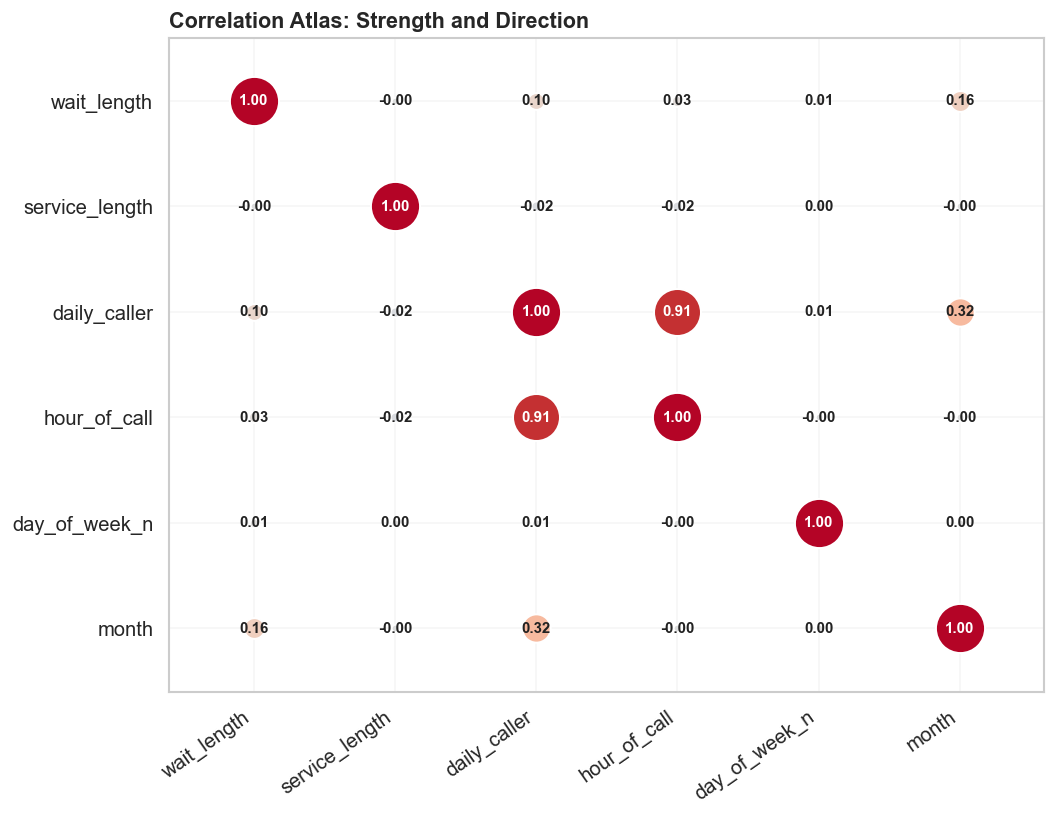

In [50]:
numeric_df = df[['wait_length', 'service_length', 'daily_caller', 'hour_of_call', 'day_of_week_n', 'month']]
corr_matrix = numeric_df.corr()

fig, ax = plt.subplots(figsize=(9, 7))
for row, row_name in enumerate(corr_matrix.index):
    for col, col_name in enumerate(corr_matrix.columns):
        value = corr_matrix.iloc[row, col]
        ax.scatter(col, row, s=850 * abs(value) + 20, c=[value], cmap='coolwarm', vmin=-1, vmax=1,
                   edgecolors='white', linewidths=1.2)
        ax.text(col, row, f'{value:.2f}', ha='center', va='center', fontsize=9,
                color='white' if abs(value) > 0.55 else '#222222', fontweight='bold')
ax.set_xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=35, ha='right')
ax.set_yticks(range(len(corr_matrix.index)), corr_matrix.index)
ax.invert_yaxis()
ax.set_title('Correlation Atlas: Strength and Direction', fontweight='bold', fontsize=13, loc='left')
ax.set_xlim(-0.6, len(corr_matrix.columns) - 0.4)
ax.set_ylim(len(corr_matrix.index) - 0.4, -0.6)
ax.grid(alpha=0.18)
plt.tight_layout()
plt.savefig('fig_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

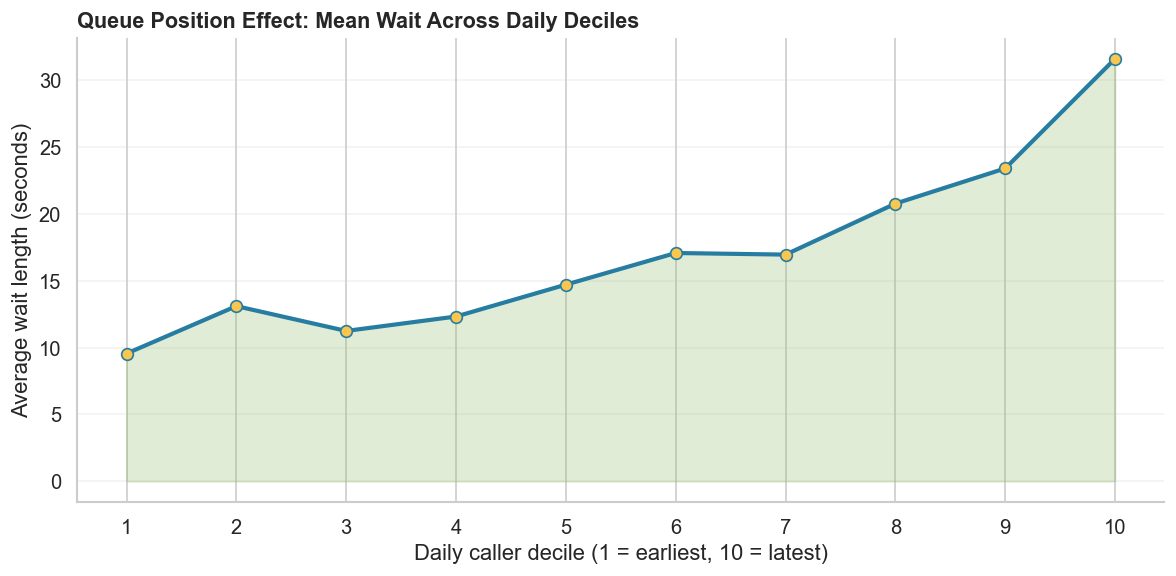

In [51]:
# wait_length vs call position decile within the day
df['caller_decile'] = pd.qcut(df['daily_caller'], q=10, labels=False, duplicates='drop') + 1
wait_by_decile = df.groupby('caller_decile')['wait_length'].mean().reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
ax.fill_between(wait_by_decile['caller_decile'], wait_by_decile['wait_length'],
                color='#90be6d', alpha=0.28)
ax.plot(wait_by_decile['caller_decile'], wait_by_decile['wait_length'],
        color='#277da1', linewidth=2.5, marker='o', markersize=7,
        markerfacecolor='#f9c74f', markeredgecolor='#277da1')
ax.set_title('Queue Position Effect: Mean Wait Across Daily Deciles', fontweight='bold', fontsize=13, loc='left')
ax.set_xlabel('Daily caller decile (1 = earliest, 10 = latest)')
ax.set_ylabel('Average wait length (seconds)')
ax.set_xticks(wait_by_decile['caller_decile'])
ax.grid(axis='y', alpha=0.25)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('fig_wait_by_position.png', dpi=150, bbox_inches='tight')
plt.show()

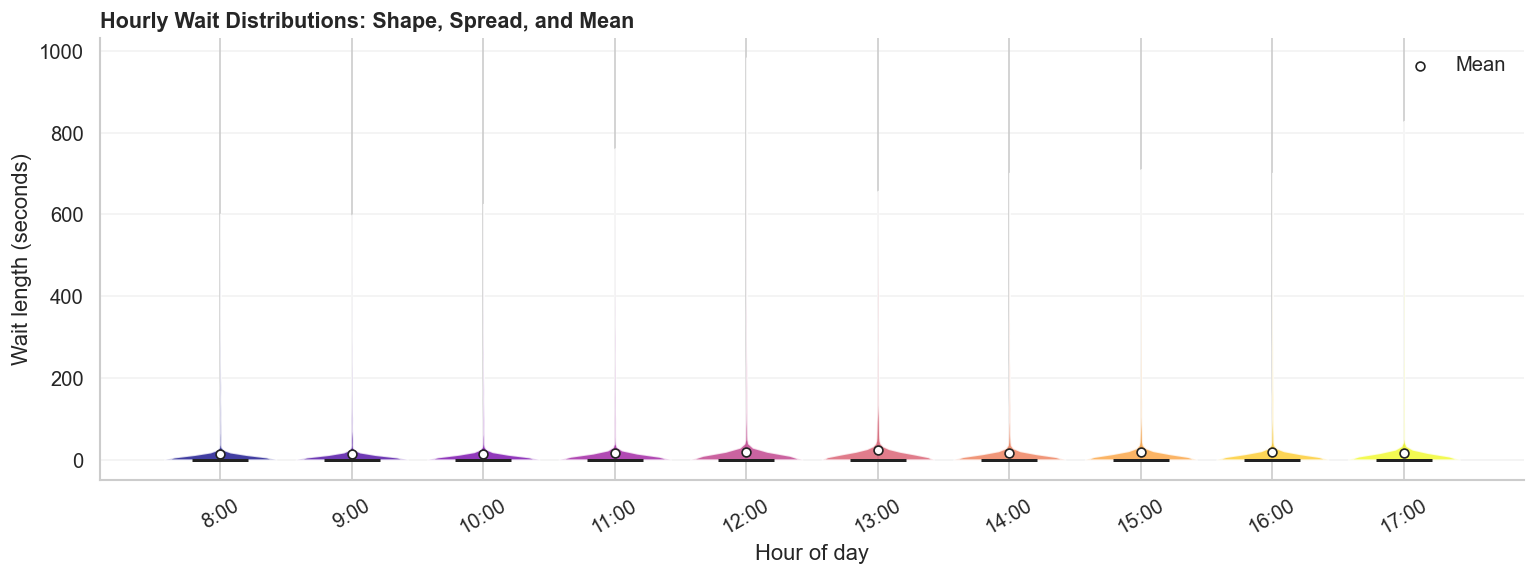

In [52]:
# Boxplot: wait_length by hour
fig, ax = plt.subplots(figsize=(13, 5))
hours = sorted(df['hour_of_call'].unique())
data_by_hour = [df.loc[df['hour_of_call'] == h, 'wait_length'].values for h in hours]

positions = np.arange(len(hours))
parts = ax.violinplot(data_by_hour, positions=positions, showmedians=True, showextrema=False, widths=0.85)
for index, body in enumerate(parts['bodies']):
    body.set_facecolor(plt.cm.plasma(index / max(1, len(hours) - 1)))
    body.set_edgecolor('white')
    body.set_alpha(0.78)
parts['cmedians'].set_color('#222222')
parts['cmedians'].set_linewidth(1.8)
means_h = [np.mean(data) for data in data_by_hour]
ax.scatter(positions, means_h, color='white', edgecolor='#222222', s=28, zorder=3, label='Mean')
ax.set_title('Hourly Wait Distributions: Shape, Spread, and Mean', fontweight='bold', fontsize=13, loc='left')
ax.set_xlabel('Hour of day')
ax.set_ylabel('Wait length (seconds)')
ax.set_xticks(positions, [f'{h}:00' for h in hours], rotation=30)
ax.legend(frameon=False)
ax.grid(axis='y', alpha=0.25)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('fig_wait_by_hour_box.png', dpi=150, bbox_inches='tight')
plt.show()

Pairwise correlations are limited, so queue behaviour is mainly sequential. Time of day, caller position, and recent service history provide more useful context than isolated values.

## 19. Three Key Findings

Waiting time is mostly zero but has a long right tail, so a transformed target or two-stage approach may be useful. Hourly patterns affect the probability of waiting, so time features should be included. The chronological order and autocorrelation show that random splitting could leak future information, making a time-based split necessary.

Percentage of zero-wait calls : 87.6%
Raw wait_length skewness      : 5.260
log(1+wait_length) skewness   : 2.550


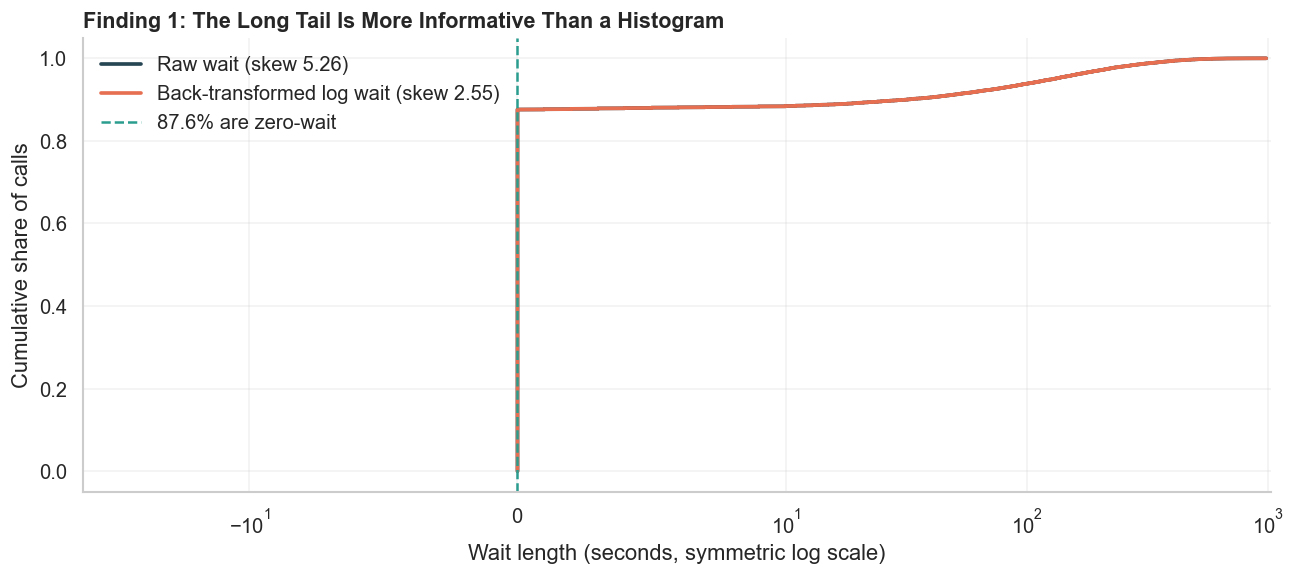

In [53]:
pct_zero = (df['wait_length'] == 0).mean() * 100
skew_raw = df['wait_length'].skew()
skew_log = np.log1p(df['wait_length']).skew()

print(f'Percentage of zero-wait calls : {pct_zero:.1f}%')
print(f'Raw wait_length skewness      : {skew_raw:.3f}')
print(f'log(1+wait_length) skewness   : {skew_log:.3f}')

fig, ax = plt.subplots(figsize=(11, 5))
raw_sorted = np.sort(df['wait_length'])
log_sorted = np.sort(np.log1p(df['wait_length']))
probability = np.linspace(0, 1, len(df), endpoint=False) + 1 / len(df)
ax.plot(raw_sorted, probability, color='#264653', linewidth=2.2, label=f'Raw wait (skew {skew_raw:.2f})')
ax.plot(np.expm1(log_sorted), probability, color='#e76f51', linewidth=2.2, label=f'Back-transformed log wait (skew {skew_log:.2f})')
ax.axvline(0, color='#2a9d8f', linestyle='--', linewidth=1.5, label=f'{pct_zero:.1f}% are zero-wait')
ax.set_xscale('symlog', linthresh=10)
ax.set_title('Finding 1: The Long Tail Is More Informative Than a Histogram', fontsize=13, fontweight='bold', loc='left')
ax.set_xlabel('Wait length (seconds, symmetric log scale)')
ax.set_ylabel('Cumulative share of calls')
ax.legend(frameon=False)
ax.grid(alpha=0.25)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('fig_finding1.png', dpi=150, bbox_inches='tight')
plt.show()

**Finding 1 implication:** Use a transformed target or a two-stage model because most waits are zero and the remaining values have a long right tail. Robust losses such as MAE or Huber are preferable to relying only on MSE.

Hourly call statistics:
 hour_of_call  total_calls  avg_wait  pct_waited
            8         5434   13.7468     10.9864
            9         5099   12.6225     11.9631
           10         5102   13.7087     11.7405
           11         5103   16.0004     11.2875
           12         5236   19.4992     12.1849
           13         5258   23.3165     15.0247
           14         5270   17.1102     12.7894
           15         5305   18.9361     13.8360
           16         5225   18.0725     13.3397
           17         4676   17.2019     10.7357


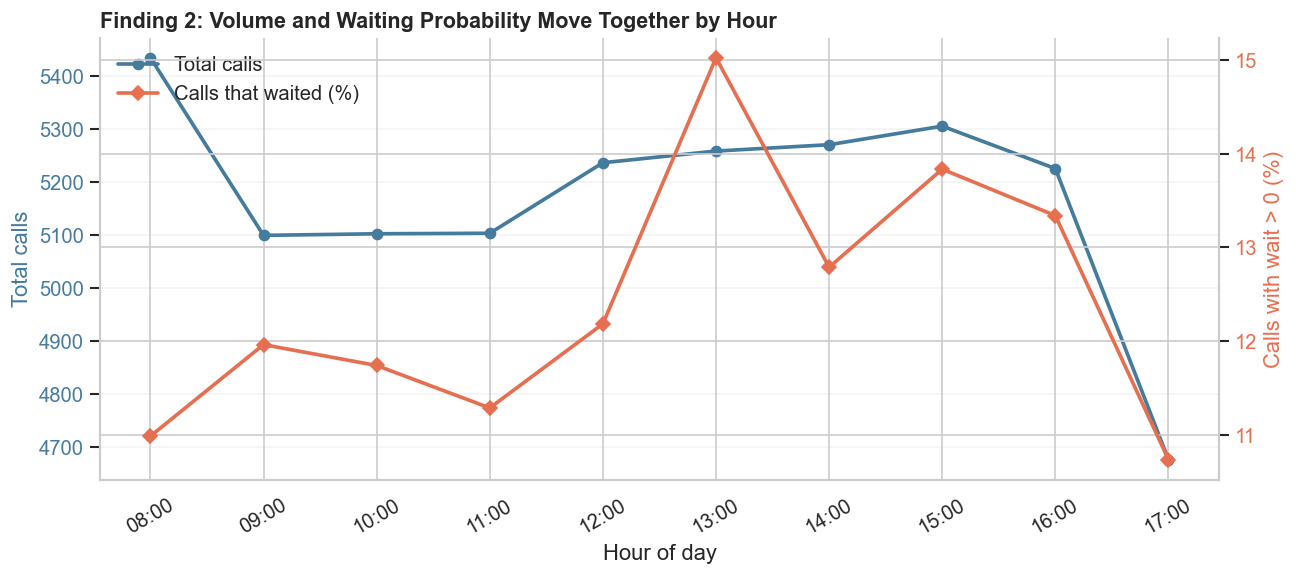

In [54]:
hourly_stats = df.groupby('hour_of_call').agg(
    total_calls=('wait_length', 'count'),
    avg_wait=('wait_length', 'mean'),
    pct_waited=('wait_length', lambda x: (x > 0).mean() * 100)
).reset_index()

print('Hourly call statistics:')
print(hourly_stats.to_string(index=False))

fig, ax = plt.subplots(figsize=(11, 5))
ax2 = ax.twinx()
ax.plot(hourly_stats['hour_of_call'], hourly_stats['total_calls'], color='#457b9d', marker='o',
        linewidth=2.2, label='Total calls')
ax2.plot(hourly_stats['hour_of_call'], hourly_stats['pct_waited'], color='#e76f51', marker='D',
         linewidth=2.2, label='Calls that waited (%)')
ax.set_title('Finding 2: Volume and Waiting Probability Move Together by Hour',
             fontsize=13, fontweight='bold', loc='left')
ax.set_xlabel('Hour of day')
ax.set_ylabel('Total calls', color='#457b9d')
ax2.set_ylabel('Calls with wait > 0 (%)', color='#e76f51')
ax.set_xticks(hourly_stats['hour_of_call'])
ax.set_xticklabels([f'{h:02d}:00' for h in hourly_stats['hour_of_call']], rotation=30)
ax.tick_params(axis='y', labelcolor='#457b9d')
ax2.tick_params(axis='y', labelcolor='#e76f51')
ax.grid(axis='y', alpha=0.22)
ax.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines + lines2, labels + labels2, frameon=False, loc='upper left')
plt.tight_layout()
plt.savefig('fig_finding2.png', dpi=150, bbox_inches='tight')
plt.show()

**Finding 2 implication:** Encode hour cyclically and include weekday and recent queue features. These are available before answering a new call and can support a waiting-time recommendation.

Is date monotonically increasing with call_id? True


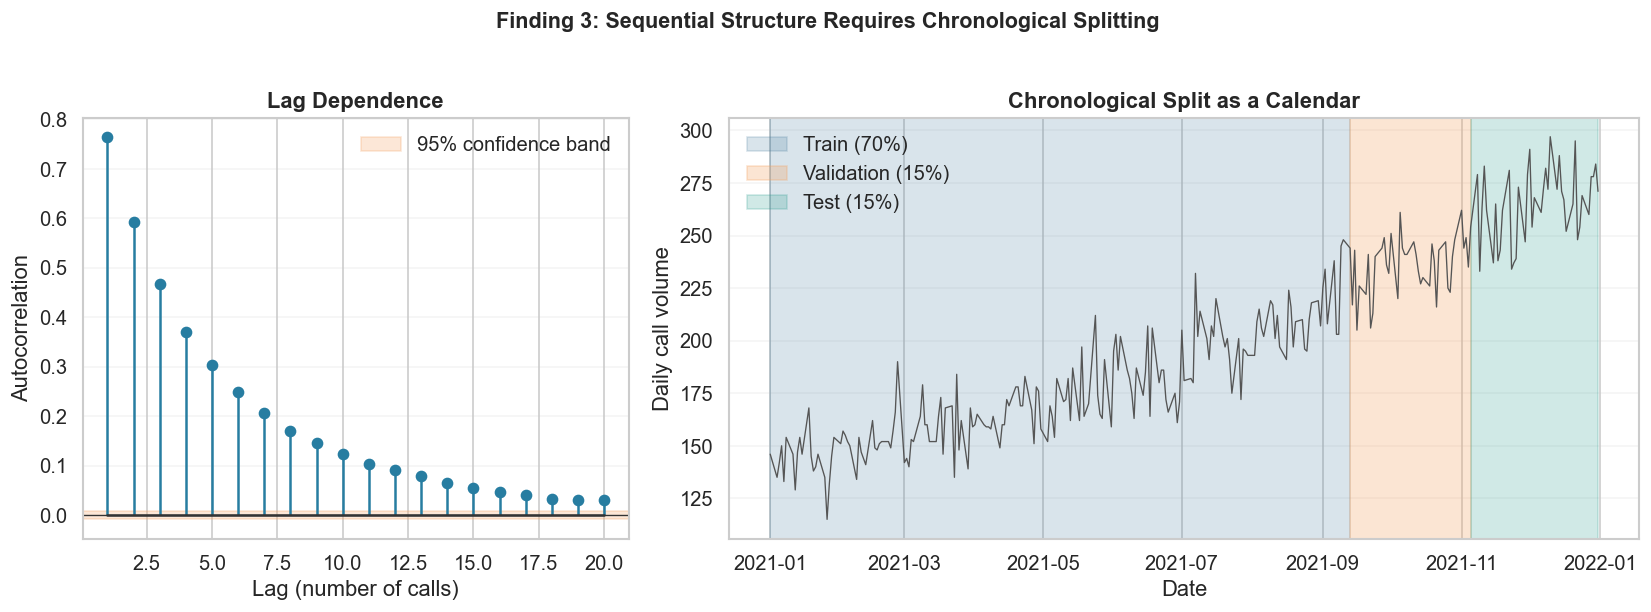

Autocorrelation at lag 1 : 0.7649
Autocorrelation at lag 5 : 0.3025
Autocorrelation at lag 10: 0.1243


In [55]:
# Verify monotonic ordering
df_sorted = df.sort_values('call_id')
is_monotonic = df_sorted['date'].is_monotonic_increasing
print(f'Is date monotonically increasing with call_id? {is_monotonic}')

# Autocorrelation of wait_length sequence
wait_series = df_sorted['wait_length'].values
n_lags = 20
autocorrs = [pd.Series(wait_series).autocorr(lag=lag) for lag in range(1, n_lags + 1)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={'width_ratios': [0.9, 1.5]})
axes[0].stem(range(1, n_lags + 1), autocorrs, linefmt='#277da1', markerfmt='o', basefmt='#333333')
axes[0].axhline(0, color='#333333', linewidth=0.8)
ci = 1.96 / np.sqrt(len(wait_series))
axes[0].axhspan(-ci, ci, color='#f4a261', alpha=0.25, label='95% confidence band')
axes[0].set_title('Lag Dependence', fontweight='bold')
axes[0].set_xlabel('Lag (number of calls)')
axes[0].set_ylabel('Autocorrelation')
axes[0].legend(frameon=False)
axes[0].grid(axis='y', alpha=0.2)

calls_per_day = df.groupby('date').size().reset_index(name='call_count')
all_dates = sorted(calls_per_day['date'].values)
n_days_total = len(all_dates)
train_end_d = all_dates[int(n_days_total * 0.70) - 1]
val_end_d = all_dates[int(n_days_total * 0.85) - 1]
axes[1].plot(calls_per_day['date'], calls_per_day['call_count'], color='#555555', linewidth=0.8)
axes[1].axvspan(calls_per_day['date'].min(), train_end_d, color='#457b9d', alpha=0.2, label='Train (70%)')
axes[1].axvspan(train_end_d, val_end_d, color='#f4a261', alpha=0.28, label='Validation (15%)')
axes[1].axvspan(val_end_d, calls_per_day['date'].max(), color='#2a9d8f', alpha=0.22, label='Test (15%)')
axes[1].set_title('Chronological Split as a Calendar', fontweight='bold')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Daily call volume')
axes[1].legend(frameon=False)
axes[1].grid(axis='y', alpha=0.2)

plt.suptitle('Finding 3: Sequential Structure Requires Chronological Splitting',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_finding3.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Autocorrelation at lag 1 : {autocorrs[0]:.4f}')
print(f'Autocorrelation at lag 5 : {autocorrs[4]:.4f}')
print(f'Autocorrelation at lag 10: {autocorrs[9]:.4f}')

**Finding 3 implication:** Use a 70/15/15 chronological train/validation/test split. Build LSTM look-back sequences separately within each partition so no sequence crosses a split boundary.

## 20. Train / Validation / Test Split Strategy

In [56]:
df_sorted_final = df.sort_values('call_id').reset_index(drop=True)

unique_dates_sorted = sorted(df_sorted_final['date'].unique())
n_days_total        = len(unique_dates_sorted)

train_cutoff = unique_dates_sorted[int(n_days_total * 0.70) - 1]
val_cutoff   = unique_dates_sorted[int(n_days_total * 0.85) - 1]

df_train = df_sorted_final[df_sorted_final['date'] <= train_cutoff]
df_val   = df_sorted_final[(df_sorted_final['date'] > train_cutoff) &
                            (df_sorted_final['date'] <= val_cutoff)]
df_test  = df_sorted_final[df_sorted_final['date'] > val_cutoff]

print('=== Chronological Train / Validation / Test Split ===')
print(f'Total operating days: {n_days_total}')
print()
print(f'TRAIN:       {len(df_train):>6,} rows | '
      f'{pd.Timestamp(df_train["date"].min()).date()} to '
      f'{pd.Timestamp(df_train["date"].max()).date()} | '
      f'{len(df_train)/len(df_sorted_final)*100:.1f}%')
print(f'VALIDATION:  {len(df_val):>6,} rows | '
      f'{pd.Timestamp(df_val["date"].min()).date()} to '
      f'{pd.Timestamp(df_val["date"].max()).date()} | '
      f'{len(df_val)/len(df_sorted_final)*100:.1f}%')
print(f'TEST:        {len(df_test):>6,} rows | '
      f'{pd.Timestamp(df_test["date"].min()).date()} to '
      f'{pd.Timestamp(df_test["date"].max()).date()} | '
      f'{len(df_test)/len(df_sorted_final)*100:.1f}%')

=== Chronological Train / Validation / Test Split ===
Total operating days: 261

TRAIN:       31,898 rows | 2021-01-01 to 2021-09-13 | 61.7%
VALIDATION:   9,206 rows | 2021-09-14 to 2021-11-05 | 17.8%
TEST:        10,604 rows | 2021-11-08 to 2021-12-31 | 20.5%


A chronological split is justified since the phone calls depend on the prior queue conditions. The split of the dataset is based on operational days with 70% training, 15% validation, and 15% test sets. The sequence windows need to be generated independently in each split to avoid leakage.

## 21. Future Modelling Decisions

The prediction model for the future will include the variables hour, weekday, caller location, and the wait and service history up until now. Since the waits are skewed to the right, `log1p`, MAE, or even Huber loss might improve things. Short sequences of 10 to 30 calls, as well as a time-based split, will have to be tested.

## 22. Conclusion

The EDA was conducted on 51,708 synthetic phone calls generated over 261 weekdays in 2021. There are no significant quality issues in this data, except for zero-inflation and right skewness in waiting times. Hour of call, weekday, position in the queue, and recent queue history are variables to consider. For modeling using RNN/LSTM, chronological splitting needs to be done next.